###Q Learning (Reinfocement) on Adult income Dataset

In [1]:
import pandas as pd
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt



In [2]:
train_df = pd.read_csv("adult_income_train_preprocessed_cleaned.csv")
test_df = pd.read_csv("adult_income_test_preprocessed_cleaned.csv")

In [3]:
from sklearn.preprocessing import StandardScaler

X_train = train_df.iloc[:, :-1]
y_train = train_df.iloc[:, -1]

X_test = test_df.iloc[:, :-1]
y_test = test_df.iloc[:, -1]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Data scaling complete.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Data scaling complete.
X_train_scaled shape: (39073, 89)
X_test_scaled shape: (9769, 89)


In [4]:
q_table = {}

def get_q_values(state_key):
    """Retrieves or initializes Q-values [Action 0, Action 1] for a given state tuple."""
    if state_key not in q_table:
        q_table[state_key] = np.zeros(2)
    return q_table[state_key]

train_features = X_train_scaled
train_labels = y_train.values
def get_state_representation(row_vector):
    return tuple(np.round(row_vector, 1))





In [5]:

# Configure Hyperparameters directly from Week 10 slides
alpha = 0.1         # Learning rate (TD step size parameter)
gamma = 0.9         # Discount factor (importance of downstream states)
initial_epsilon = 0.2 # Initial Epsilon-greedy parameter for action selection exploration
min_epsilon = 0.01  # Minimum epsilon value to decay to
episodes = 2000     # Total sequential training episodes
epsilon_decay_rate = (initial_epsilon - min_epsilon) / episodes # Linear decay rate
steps_per_episode = 10  # Multi-step depth per episode loop

reward_history = []
epsilon_history = [] # Initialize list to store epsilon values for plotting

print(f"Beginning off-policy Q-learning over {episodes} episodic sequences...")


Beginning off-policy Q-learning over 2000 episodic sequences...


In [6]:
# Training Loop (Matching Slide Algorithm)
epsilon = initial_epsilon
for episode in range(episodes):
    epsilon_history.append(epsilon)
    epsilon = max(min_epsilon, epsilon - epsilon_decay_rate)
    idx = random.randint(0, len(train_features) - 2)
    state_vector = train_features[idx]
    S = get_state_representation(state_vector)

    total_episode_reward = 0

    for step in range(steps_per_episode):
        q_values_S = get_q_values(S)

        if random.uniform(0, 1) < epsilon:
            A = random.randint(0, 1)
        else:
            A = np.argmax(q_values_S)

        actual_target = train_labels[idx]
        if A == actual_target:
            R = 1.0
        else:
            R = -2.0 if actual_target == 1 else -1.0

        total_episode_reward += R

        idx += 1
        if idx >= len(train_features):
            idx = 0

        next_state_vector = train_features[idx]
        S_prime = get_state_representation(next_state_vector)
        q_values_S_prime = get_q_values(S_prime)
        max_q_S_prime = np.max(q_values_S_prime)
        q_table[S][A] = q_table[S][A] + alpha * (R + gamma * max_q_S_prime - q_table[S][A])

        S = S_prime

    reward_history.append(total_episode_reward)

print("Q-Table policy optimization completed successfully!")

Q-Table policy optimization completed successfully!


In [7]:
test_features = X_test_scaled
test_labels = y_test.values

test_predictions = []

print("Running test matrix policy validation...")

for i in range(len(test_features)):
    test_row = test_features[i]
    distances = np.sum(np.abs(train_features - test_row), axis=1)
    closest_trained_idx = np.argmin(distances)

    matched_state_key = get_state_representation(train_features[closest_trained_idx])
    best_action = np.argmax(get_q_values(matched_state_key))
    test_predictions.append(best_action)


test_predictions = np.array(test_predictions)
final_rl_accuracy = np.mean(test_predictions == test_labels)
print(f"\nQ-Learning Agent Test Accuracy: {final_rl_accuracy * 100:.2f}%")

Running test matrix policy validation...

Q-Learning Agent Test Accuracy: 78.33%


Balanced Accuracy: 60.41%
Weighted F1-Score: 74.87%
Macro F1-Score: 61.73%


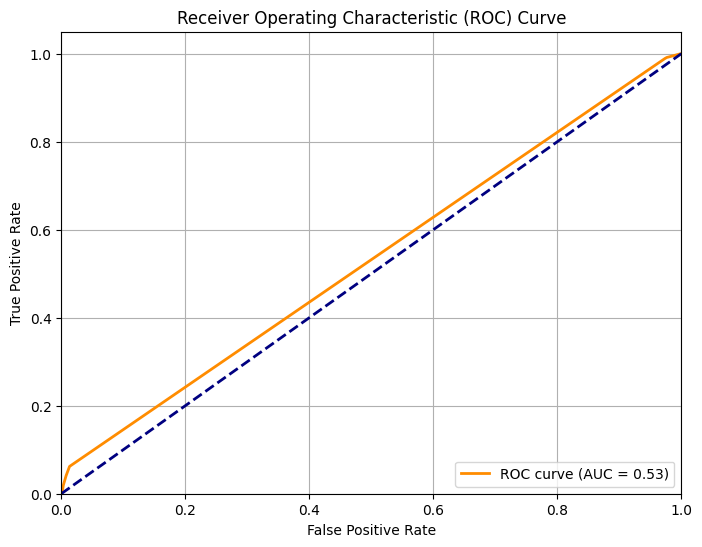

In [8]:
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt

test_predictions_final = []
q_scores_positive_class = []

print("Collecting Q-scores for detailed evaluation...")

for i in range(len(test_features)):
    test_row = test_features[i]

    distances = np.sum(np.abs(train_features - test_row), axis=1)
    closest_trained_idx = np.argmin(distances)

    matched_state_key = get_state_representation(train_features[closest_trained_idx])
    q_values = get_q_values(matched_state_key)

    best_action = np.argmax(q_values)
    test_predictions_final.append(best_action)
    q_scores_positive_class.append(q_values[1])

test_predictions_final = np.array(test_predictions_final)
q_scores_positive_class = np.array(q_scores_positive_class)

# Calculate Balanced Accuracy
balanced_acc = balanced_accuracy_score(test_labels, test_predictions_final)
print(f"Balanced Accuracy: {balanced_acc * 100:.2f}%")

# Calculate Weighted F1-Score
f1_weighted = f1_score(test_labels, test_predictions_final, average='weighted')
print(f"Weighted F1-Score: {f1_weighted * 100:.2f}%")

# Calculate Macro F1-Score
f1_macro = f1_score(test_labels, test_predictions_final, average='macro')
print(f"Macro F1-Score: {f1_macro * 100:.2f}%")

# Calculate ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(test_labels, q_scores_positive_class)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

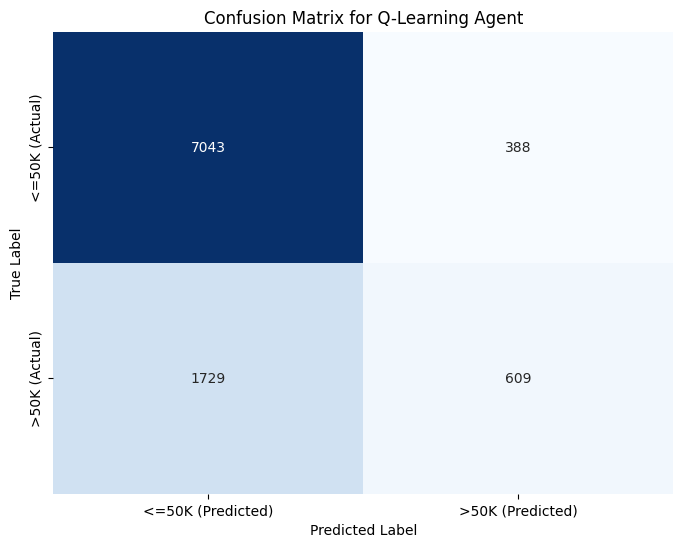

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(test_labels, test_predictions_final)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['<=50K (Predicted)', '>50K (Predicted)'],
            yticklabels=['<=50K (Actual)', '>50K (Actual)'])
plt.title('Confusion Matrix for Q-Learning Agent')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

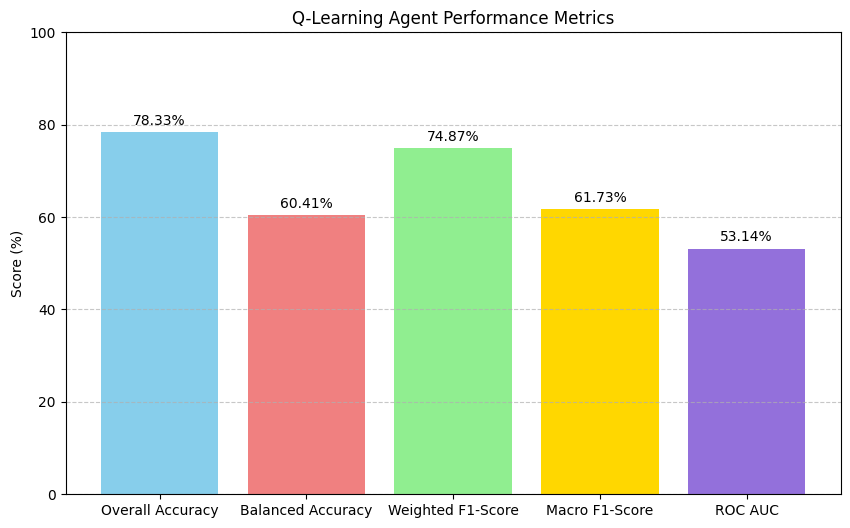

In [10]:
import matplotlib.pyplot as plt
import numpy as np

metrics = {
    'Overall Accuracy': final_rl_accuracy,
    'Balanced Accuracy': balanced_acc,
    'Weighted F1-Score': f1_weighted,
    'Macro F1-Score': f1_macro,
    'ROC AUC': roc_auc
}

metric_names = list(metrics.keys())
metric_values = [value * 100 for value in metrics.values()] # Convert to percentage for display

plt.figure(figsize=(10, 6))
plt.bar(metric_names, metric_values, color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'mediumpurple'])
plt.ylabel('Score (%)')
plt.title('Q-Learning Agent Performance Metrics')
plt.ylim(0, 100) # Assuming scores are between 0 and 100%

# Add value labels on top of each bar
for i, value in enumerate(metric_values):
    plt.text(i, value + 1, f'{value:.2f}%', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

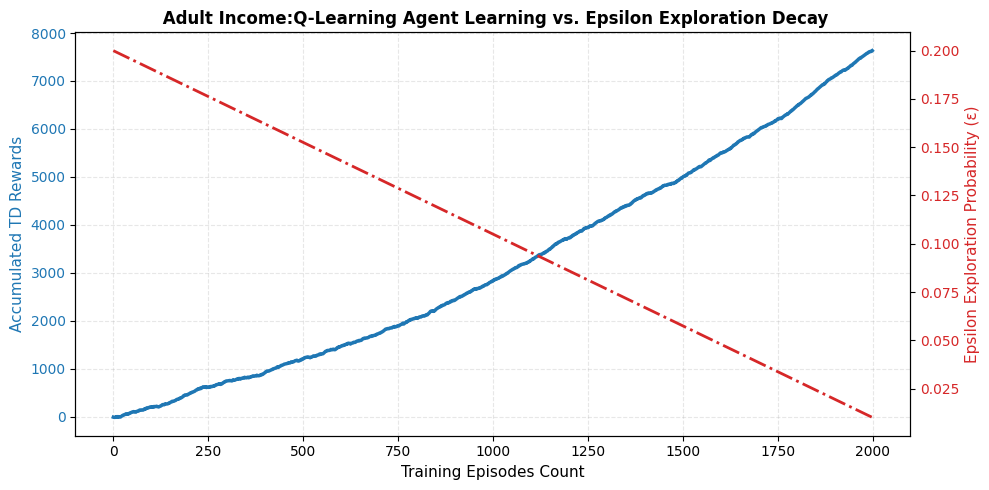

In [11]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot 1: Cumulative Reward (Left Axis)
color = 'tab:blue'
ax1.set_xlabel('Training Episodes Count', fontsize=11)
ax1.set_ylabel('Accumulated TD Rewards', color=color, fontsize=11)
ax1.plot(np.cumsum(reward_history), color=color, lw=2.5, label='Cumulative Reward')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.3)

# Plot 2: Epsilon Decay Policy (Right Axis)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Epsilon Exploration Probability (ε)', color=color, fontsize=11)
ax2.plot(epsilon_history, color=color, lw=2, linestyle='-.', label='Epsilon Decay Path')
ax2.tick_params(axis='y', labelcolor=color)

plt.title(' Adult Income:Q-Learning Agent Learning vs. Epsilon Exploration Decay', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

In [12]:
import pandas as pd

metrics_df = pd.DataFrame(metrics, index=['Score']).T

metrics_df['Score'] = metrics_df['Score'] * 100

metrics_df.to_csv('AdultIncome_q_learning_performance_metrics.csv', float_format='%.2f')

print("Performance metrics saved to 'q_learning_performance_metrics.csv'")
print(metrics_df)

Performance metrics saved to 'q_learning_performance_metrics.csv'
                       Score
Overall Accuracy   78.329409
Balanced Accuracy  60.413267
Weighted F1-Score  74.869304
Macro F1-Score     61.728129
ROC AUC            53.139062
